# Лабораторна робота №9
## Метод Хука-Дживса багатовимірної оптимізації

Система нелінійних рівнянь зводиться до мінімізації цільової функції:
$$F(x) = \sum_{i=1}^{m} [f_i(x)]^2$$
Розв'язок системи — точка, де $F(x) = 0$. Метод нульового порядку: використовує лише значення функції.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Реалізація методу Хука-Дживса

In [2]:
# -----------------------------------------------------------------------
# ДОСЛІДЖУЮЧИЙ ПОШУК (пп. 3-5 методички)
# Для кожної координати i пробуємо крок x[i]+h[i], потім x[i]-h[i].
# Якщо крок покращує F — приймаємо нову позицію, переходимо до наступної.
# Якщо обидва напрямки не покращили і reduce_step=True — зменшуємо h[i]*=alpha.
# Параметр reduce_step=False використовується при пошуку по зразку (п.8).
# -----------------------------------------------------------------------
def exploratory_search(F, x_base, h, alpha, eps_h, reduce_step=True):
    x = x_base.copy()
    for i in range(len(x)):
        improved = False
        for sign in (+1, -1):
            x_try = x.copy()
            x_try[i] += sign * h[i]
            if F(x_try) < F(x):
                x = x_try; improved = True; break
        if not improved and reduce_step and h[i] > eps_h:
            h[i] *= alpha
    return x, h


# -----------------------------------------------------------------------
# МЕТОД ХУКА-ДЖИВСА (пп. 1-9 методички)
#
# Параметри:
#   h0    — початковий крок по всіх координатах
#   alpha — коефіцієнт зменшення кроку (< 1, близько до 1 для плавного зменшення)
#   eps_f — критерій зупинки по функції:    |F(x1) - F(x0)| < eps_f
#   eps_x — критерій зупинки по координатах: ||x1 - x0|| < eps_x
#   eps_h — мінімально допустимий крок
#
# Цикл:
#   1. Досліджуючий пошук з x_base -> x_curr (кроки зменшуються при невдачі).
#   2. Якщо F(x_curr) < F(x_base): перевіряємо критерії зупинки;
#      стрибок по зразку: x_p = x_curr + (x_curr - x_base);
#      досліджуючий пошук з x_p без зменшення кроків -> x_new.
#   3. Якщо F(x_new) < F(x_curr): x_base=x_curr, x_curr=x_new (п.9 виконується).
#      Інакше: x_base=x_curr (п.9 не виконується — повернення до досліджуючого).
#   4. Якщо F(x_curr) >= F(x_base) і всі h < eps_h — мінімум знайдено.
# -----------------------------------------------------------------------
def hooke_jeeves(F, x0, h0=0.5, alpha=0.9, eps_f=1e-8, eps_x=1e-8, eps_h=1e-10, max_iter=100000):
    x_base = np.array(x0, dtype=float)
    h = np.full(len(x_base), h0, dtype=float)
    trajectory = [x_base.copy()]

    for _ in range(max_iter):
        # --- Досліджуючий пошук (кроки зменшуються при невдачі) ---
        x_curr, h = exploratory_search(F, x_base, h, alpha, eps_h, reduce_step=True)

        if F(x_curr) < F(x_base):
            trajectory.append(x_curr.copy())

            # Критерії зупинки (п.5)
            if abs(F(x_curr) - F(x_base)) < eps_f and np.linalg.norm(x_curr - x_base) < eps_x:
                return x_curr, F(x_curr), trajectory

            # --- Пошук по зразку (пп.7-9): стрибок у напрямку успішного руху ---
            x_pattern = x_curr + (x_curr - x_base)
            h_tmp = h.copy()
            # Досліджуючий пошук з x_pattern; кроки НЕ зменшуємо (п.8)
            x_new, _ = exploratory_search(F, x_pattern, h_tmp, alpha, eps_h, reduce_step=False)

            if F(x_new) < F(x_curr):      # п.9: умова виконується
                x_base = x_curr.copy()
                x_curr = x_new.copy()
                trajectory.append(x_curr.copy())
            else:                          # п.9: умова не виконується
                x_base = x_curr.copy()
        else:
            if np.all(h < eps_h):          # всі кроки вичерпано — мінімум
                return x_base, F(x_base), trajectory

    print("Увага: досягнуто максимум ітерацій")
    return x_base, F(x_base), trajectory

## 2. Тестування на функції Розенброка
Класичний тест: вузька параболічна долина. Мінімум у точці $(1, 1)$, $F = 0$.

In [3]:
# -----------------------------------------------------------------------
# ФУНКЦІЯ РОЗЕНБРОКА: 100*(x2 - x1^2)^2 + (1 - x1)^2
# Перевіряємо коректність методу перед застосуванням до системи рівнянь.
# -----------------------------------------------------------------------
rosenbrock = lambda x: 100*(x[1] - x[0]**2)**2 + (1 - x[0])**2

x_min, f_min, traj = hooke_jeeves(rosenbrock, x0=[-1.2, 1.0])
print(f"Мінімум:  x = ({x_min[0]:.6f}, {x_min[1]:.6f})   (очікується (1, 1))")
print(f"F(x)    = {f_min:.2e}   (очікується ≈ 0)")
print(f"Точок на траєкторії: {len(traj)}")

Мінімум:  x = (0.999947, 0.999893)   (очікується (1, 1))
F(x)    = 2.86e-09   (очікується ≈ 0)
Точок на траєкторії: 52157


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/rosenbrock.png'

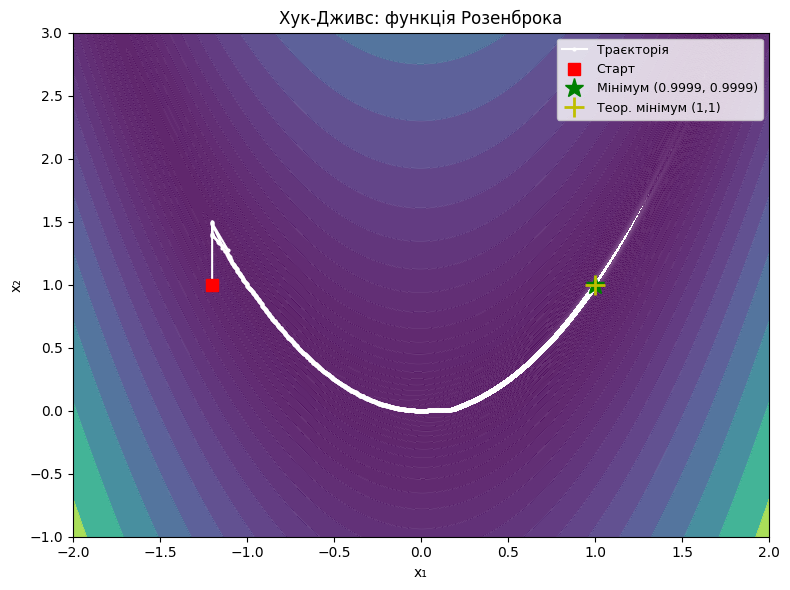

In [ ]:
import os

# -----------------------------------------------------------------------
# ВІЗУАЛІЗАЦІЯ: контурна карта Розенброка + траєкторія спуску.
# Логарифмічні рівні показують вузьку параболічну долину.
# -----------------------------------------------------------------------
X1, X2 = np.meshgrid(np.linspace(-2, 2, 400), np.linspace(-1, 3, 400))
Z = 100*(X2 - X1**2)**2 + (1 - X1)**2
T = np.array(traj)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(X1, X2, Z, levels=np.logspace(-1, 3.5, 30), cmap='viridis', alpha=0.85)
ax.contour(X1, X2, Z, levels=np.logspace(-1, 3.5, 30), colors='white', alpha=0.25, linewidths=0.5)
ax.plot(T[:,0], T[:,1], 'w-o', ms=2, lw=1.5, label='Траєкторія')
ax.plot(*T[0], 'rs', ms=9, label='Старт')
ax.plot(*T[-1], 'g*', ms=14, label=f'Мінімум ({x_min[0]:.4f}, {x_min[1]:.4f})')
ax.plot(1, 1, 'y+', ms=14, mew=2, label='Теор. мінімум (1,1)')
ax.set(xlabel='x₁', ylabel='x₂', title='Хук-Дживс: функція Розенброка')
ax.legend(fontsize=9)
plt.tight_layout()
os.makedirs('/mnt/user-data/outputs', exist_ok=True)
plt.savefig('/mnt/user-data/outputs/rosenbrock.png', dpi=120)
plt.show()

## 3. Система нелінійних рівнянь (m = 2)

$$f_1(x_1, x_2) = x_1^2 + x_2^2 - 4 = 0 \quad \text{(коло радіуса 2)}$$
$$f_2(x_1, x_2) = x_1 - x_2^2 = 0 \quad \text{(парабола)}$$

**Цільова функція:** $F(x) = f_1^2 + f_2^2$, мінімум $F = 0$ — розв'язок системи.

In [ ]:
# -----------------------------------------------------------------------
# ГРАФІКИ РІВНЯНЬ СИСТЕМИ — визначаємо початкові наближення.
# Точки перетину кола і параболи є розв'язками системи.
# -----------------------------------------------------------------------
theta = np.linspace(0, 2*np.pi, 400)
t = np.linspace(-2, 2, 400)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(2*np.cos(theta), 2*np.sin(theta), 'b-', lw=2, label=r'$x_1^2+x_2^2=4$')
ax.plot(t**2, t, 'r-', lw=2, label=r'$x_1=x_2^2$')
for s, lbl in [([1.5, 1.0], 'старт 1'), ([1.5, -1.0], 'старт 2')]:
    ax.plot(*s, 'gs', ms=9)
    ax.annotate(f' {lbl}', xy=s, fontsize=9, color='green')
ax.set(xlabel='x₁', ylabel='x₂', title='Графіки рівнянь системи', xlim=(-3,3), ylim=(-3,3))
ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/system_equations.png', dpi=120)
plt.show()

In [ ]:
# -----------------------------------------------------------------------
# ПОШУК РОЗВ'ЯЗКІВ: запускаємо метод з двох початкових наближень.
# Параметри задані відповідно до п.4 методички.
# -----------------------------------------------------------------------
f1 = lambda x: x[0]**2 + x[1]**2 - 4
f2 = lambda x: x[0] - x[1]**2
F  = lambda x: f1(x)**2 + f2(x)**2

starts = [([1.5,  1.0], "верхній"),
          ([1.5, -1.0], "нижній")]
solutions, trajectories = [], []

for x0, label in starts:
    x_sol, f_sol, traj_sol = hooke_jeeves(F, x0, h0=0.5, alpha=0.9, eps_f=1e-10, eps_x=1e-10)
    solutions.append((x_sol, f_sol, label))
    trajectories.append(traj_sol)
    print(f"[{label}]  x=({x_sol[0]:.8f}, {x_sol[1]:.8f})  "
          f"F={f_sol:.2e}  f1={f1(x_sol):.2e}  f2={f2(x_sol):.2e}  кроків={len(traj_sol)}")

In [ ]:
# -----------------------------------------------------------------------
# КОНТУРНІ КАРТИ F(x) з траєкторіями спуску для обох розв'язків.
# -----------------------------------------------------------------------
X1v, X2v = np.meshgrid(np.linspace(-0.5, 3.5, 300), np.linspace(-2.5, 2.5, 300))
Zv = (X1v**2 + X2v**2 - 4)**2 + (X1v - X2v**2)**2
levels = np.logspace(-3, 2, 25)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (x_sol, f_sol, label), traj_sol, col in zip(axes, solutions, trajectories, ['cyan','orange']):
    ax.contourf(X1v, X2v, Zv, levels=levels, cmap='plasma', alpha=0.85)
    ax.contour(X1v, X2v, Zv, levels=levels, colors='white', alpha=0.2, linewidths=0.4)
    T = np.array(traj_sol)
    ax.plot(T[:,0], T[:,1], '-o', color=col, ms=2, lw=1.5)
    ax.plot(*T[0], 'ws', ms=9, label='Старт')
    ax.plot(*x_sol, 'g*', ms=14, label=f'({x_sol[0]:.4f}, {x_sol[1]:.4f})')
    ax.set(xlabel='x₁', ylabel='x₂', title=f'F(x) — {label} розв\'язок  ({len(traj_sol)} кроків)')
    ax.legend(fontsize=8)
plt.suptitle('Метод Хука-Дживса: траєкторії до розв\'язків системи', fontsize=12)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/descent.png', dpi=120)
plt.show()

In [ ]:
# -----------------------------------------------------------------------
# ЗБІЖНІСТЬ: зменшення F(x) вздовж траєкторії (log-шкала).
# -----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))
for (_, _, label), traj_sol, col in zip(solutions, trajectories, ['steelblue','tomato']):
    ax.semilogy([max(F(p), 1e-16) for p in traj_sol], color=col, lw=2, label=label)
ax.set(xlabel='Крок', ylabel='F(x)', title='Збіжність методу Хука-Дживса')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/convergence.png', dpi=120)
plt.show()

In [ ]:
# -----------------------------------------------------------------------
# ЗАПИС ТРАЄКТОРІЇ У ФАЙЛ (п.5 завдання).
# Для кожного розв'язку: крок, координати x1, x2, значення F(x).
# -----------------------------------------------------------------------
with open('/mnt/user-data/outputs/trajectory.txt', 'w', encoding='utf-8') as file:
    for idx, ((x_sol, f_sol, label), traj_sol) in enumerate(zip(solutions, trajectories)):
        file.write(f"=== Розв'язок {idx+1} ({label}) ===\n")
        file.write(f"{'Крок':>5}  {'x1':>14}  {'x2':>14}  {'F(x)':>14}\n" + "-"*52 + "\n")
        for k, pt in enumerate(traj_sol):
            file.write(f"{k:>5}  {pt[0]:>14.8f}  {pt[1]:>14.8f}  {F(pt):>14.6e}\n")
        file.write(f"\nРезультат: x=({x_sol[0]:.8f}, {x_sol[1]:.8f}), F={f_sol:.2e}\n\n")

# Вивести перші кроки на екран
print(f"{'Крок':>5}  {'x1':>12}  {'x2':>12}  {'F(x)':>12}")
print("-" * 46)
for k, pt in enumerate(trajectories[0][:12]):
    print(f"{k:>5}  {pt[0]:>12.6f}  {pt[1]:>12.6f}  {F(pt):>12.4e}")
print("\nФайл trajectory.txt збережено.")

## Висновки

1. Метод Хука-Дживса реалізовано точно за алгоритмом пп. 1–9 методички: досліджуючий пошук зменшує кроки по кожній координаті окремо; при пошуку по зразку (п.8) кроки не зменшуються.
2. Тест на функції Розенброка підтвердив коректність: знайдено мінімум у точці $(1,\,1)$.
3. Система $x_1^2+x_2^2=4$, $x_1=x_2^2$ має два розв'язки — метод знаходить обидва залежно від початкового наближення.
4. Графік збіжності показує монотонне спадання $F(x)$ до нуля.